In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform
from scipy import stats
import scipy


# Simulation and estimation in a Markov model of breast cancer

# Part 1: A discrete-time model

## Task 1

In [316]:
def sim_liftime_women(P):
   possible_states = np.arange(5)
   state_history = [0]
   current_state = 0

   while current_state != 4:
    current_state = np.random.choice(possible_states, p = P[current_state])
    state_history.append(current_state)

   return np.array(state_history)

In [317]:
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])
sim_liftime_women(P)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 4])

In [318]:
np.random.seed(42)


P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

n = 1000
life_time = []
women_with_local_cancer = 0

for i in range(n):
    X = sim_liftime_women(P)
    life_time.append(len(X))
    if 1 in X: 
        women_with_local_cancer += 1
    elif 3 in X: 
        women_with_local_cancer += 1

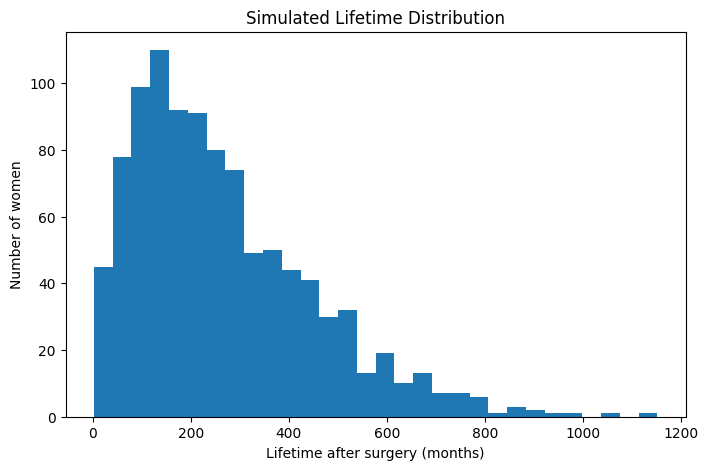

In [319]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(life_time, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

In [320]:
women_with_local_cancer/n

0.712

## Task 2

In [321]:
# Theoretical distribution at time 120 
p0 = np.array([1, 0, 0, 0, 0])
n = 1000
times = [120]  # months

print("\nAnalytical state distributions:")
for t in times:
    Pt = np.linalg.matrix_power(P, t)
    exp_state_120 = (p0 @ Pt)*n

    print(f"\nt = {t} months")
    print("Theorical state distribution")
    print(f"{exp_state_120}")



Analytical state distributions:

t = 120 months
Theorical state distribution
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]


In [322]:
np.random.seed(42)
n = 1000
emp_state_120 = []
for i in range(n):
    X = sim_liftime_women(P)
    if len(X)>= 120: 
        emp_state_120.append(X[119])
    else:
        emp_state_120.append(4)



In [323]:
observed_120 = np.bincount(emp_state_120)
_, p_value_chi = chisquare(f_obs=observed_120, f_exp=exp_state_120)
print(f"Results of chi square test {p_value_chi}")

Results of chi square test 0.7729796996445759


## Task 3

In [324]:
#Theoretical lifetime distribution
pi= np.array([1, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

exp_pdf = []
for t in range(1, np.max(life_time) + 1):
    prop = pi@np.linalg.matrix_power(Ps,t)@ps
    exp_pdf.append(prop)


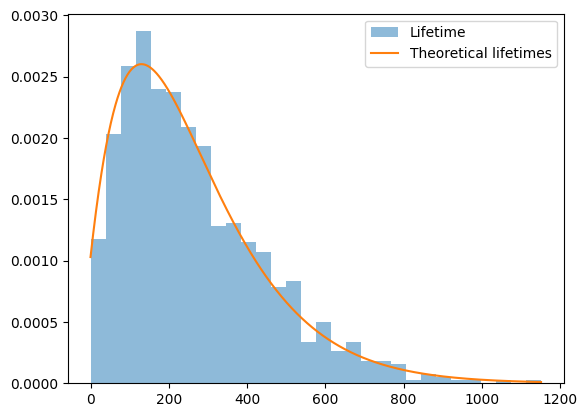

In [325]:
plt.hist(life_time, bins=30, alpha=0.5, label="Lifetime",density=True)
plt.plot(exp_pdf,label = "Theoretical lifetimes")

plt.legend()
plt.show()

## Task 4 

In [326]:
np.random.seed(42)
women_cancer_again = []
while len(women_cancer_again) != 1000: 
    X = sim_liftime_women(P)
    if (1 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

    elif (2 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

    elif (3 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

life_times_cancer_again = []
for elem in women_cancer_again:
    life_times_cancer_again.append(len(elem))


In [327]:
np.mean(life_times_cancer_again)

np.float64(179.99)

In [328]:
np.mean(life_time)

np.float64(266.035)

## Task 5 

In [329]:
def crude_monte_carlo(n,n_womens):
    fractions = []
    for _ in range(n):
        dead_after_350 = 0
        for _ in range(n_womens):
            X = sim_liftime_women(P)
            if len(X) <350:
                dead_after_350 += 1
        fractions.append(dead_after_350/200)
    
    return np.mean(fractions), np.var(fractions, ddof = 1)

In [330]:

n = 100
n_womens = 200
crude_monte_carlo(n,n_womens)

(np.float64(0.7337500000000001), np.float64(0.0009693813131313139))

In [ ]:
# Expected value
m = np.linalg.inv(np.eye(4)-Ps)
mu = pi@m@np.ones(4)



def control_variate(n,n_womens): 
    fractions = []
    for _ in range(n):
        X = np.zeros(n_womens)
        Z = []
        for i in range(n_womens):
            women = sim_liftime_women(P)
            Z.append(len(women))
            if len(women) < 350:
                X[i] = 1
        
        c = - np.cov(X,Z)[0,1]/np.var(Z)

        Y = X + c*(Z - mu)
        frac = np.mean(Y)
        fractions.append(frac)
    
    return np.mean(fractions), np.var(fractions, ddof = 1)


In [332]:

n = 100
n_womens = 200
control_variate(n,n_womens)

(np.float64(0.7379144778443542), np.float64(0.0003198494428529549))

## Task 6 

- Only register once a month, som states not registeret (may be incoorporated in probability matrix) - improvement (continues)
- In Markov chain assume that you propability of next chain only depend on current state and not the previous (might not be the case)
- P does not depend on time, but in general the older you become the higher the probability of cancer and death. Also right after operation higher propability of cancer again than if diases free along time  - could make probability matrix different depending of time (But this is hard task)
- We assume homegenous population (every women is a like, this is not the case)

- 

# Part 2: A continuous-time model

## Task 7 

In [333]:
def confidence_interval_95(results):
    results = np.asarray(results)
    n = len(results)

    mean = np.mean(results)
    std = np.std(results, ddof=1)

    t_crit = stats.t.ppf(0.975, df=n-1)

    margin = t_crit * std / np.sqrt(n)

    return (mean - margin, mean + margin)

In [334]:
def confidence_interval_std_95(results):
    results = np.asarray(results)
    n = len(results)

    s = np.std(results, ddof=1)

    chi2_lower = stats.chi2.ppf(0.025, df=n-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n-1)

    lower = np.sqrt((n - 1) * s**2 / chi2_upper)
    upper = np.sqrt((n - 1) * s**2 / chi2_lower)

    return (lower, upper)

In [335]:
def sim_liftime_women_rate(Q):
   state = 0
   time = 0 
   history = [(time,state)]


   while state != 4:
      rate = -Q[state,state]

      wait = np.random.exponential(1/rate)
      time += wait 

      probs = Q[state].copy()
      probs[state] = 0 

      probs = probs/rate

      state = np.random.choice(np.arange(5), p = probs)
      history.append((time,state))
      

   return history

In [336]:
Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0.0000, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0.0000,  0.0000, -0.0080, 0.0030, 0.0050],
    [ 0.0000,  0.0000,  0.0000, -0.0090, 0.0090],
    [ 0.0000,  0.0000,  0.0000, 0.0000, 0.0000]
])

X = sim_liftime_women_rate(Q)
X[-1][0]

92.19442430929348

In [337]:
np.random.seed(42)
n = 1000
life_time_rate= []

reapar_dist = 0 
for i in range(n):
    X = sim_liftime_women_rate(Q)
    life_time_rate.append(X[-1][0])
    for time,s in X:
        if time <= 30.5 and s in [2,3]:
            reapar_dist += 1 
            break

lifetimes_rate = np.array(life_time_rate)
mean_life =  np.mean(lifetimes_rate)
conf_mean_life = confidence_interval_95(lifetimes_rate)
std_life = np.std(lifetimes_rate,  ddof=1)
cond_std_life = confidence_interval_std_95(lifetimes_rate)
dist_cancer_again = reapar_dist/n
print(f"Life time mean {mean_life}")
print(f"Life time confidence interval for mean [{conf_mean_life}]")
print(f"Life time std {std_life}") #Why is std so high? 
print(f"Life time confidence interval for std [{cond_std_life}]")
print(f"Fraction of distant cancer again {dist_cancer_again}")


Life time mean 256.3715684046518
Life time confidence interval for mean [(np.float64(244.30943097040765), np.float64(268.43370583889595))]
Life time std 194.37915621555038
Life time confidence interval for std [(np.float64(186.2176320670264), np.float64(203.29442568598935))]
Fraction of distant cancer again 0.084


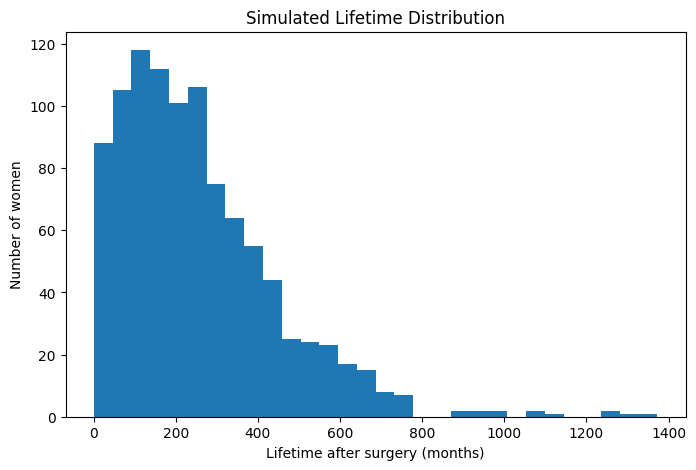

In [338]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(lifetimes_rate, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

## Task 8 

In [339]:
Qs = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000],
    [ 0.0000,-0.0140, 0.0050, 0.0040],
    [ 0.0000, 0.0000,-0.0080, 0.0030],
    [ 0.0000, 0.0000, 0.0000,-0.0090]
])

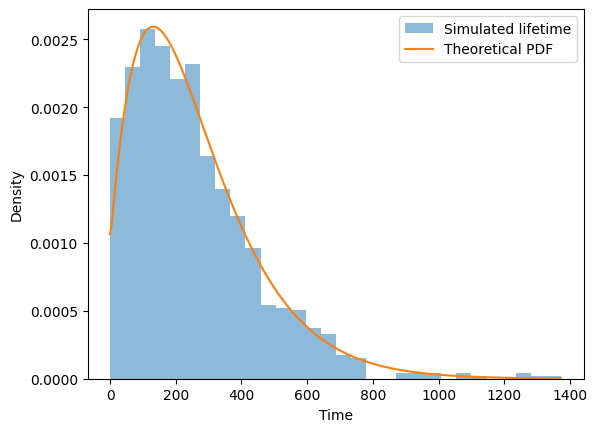

In [340]:
p0 = np.array([1, 0, 0, 0])

# make smooth time grid
max_t = np.max(life_time_rate)
times = np.linspace(0, max_t, 300)   

# compute CDF
F_cdf = []

for t in times:
    val = 1 - p0 @ scipy.linalg.expm(Qs * t) @ np.ones(4)
    F_cdf.append(val)

F_cdf = np.array(F_cdf)

# convert CDF to PDF
pdf = np.gradient(F_cdf, times)

# plot simulation histogram
plt.hist(life_time_rate, bins=30, density=True, alpha=0.5, label="Simulated lifetime")

# plot theoretical PDF (IMPORTANT: x then y)
plt.plot(times, pdf, label="Theoretical PDF")

plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.show()

In [341]:
# Chi-square test 

bins = np.linspace(0, np.max(life_time_rate), 10)

obs_counts, _ = np.histogram(life_time_rate, bins=bins)

# Compute expected counts 
expected_counts = []

for i in range(len(bins) - 1):
    t1, t2 = bins[i], bins[i+1]

    F1 = 1 - p0 @ scipy.linalg.expm(Qs * t1) @ np.ones(4)
    F2 = 1 - p0 @ scipy.linalg.expm(Qs * t2) @ np.ones(4)

    expected_counts.append(len(life_time_rate) * (F2 - F1))

expected_counts = np.array(expected_counts)

mask = expected_counts >= 5

obs_counts = obs_counts[mask]
expected_counts = expected_counts[mask]

chi2_stat = np.sum((obs_counts - expected_counts)**2 / expected_counts)

df = len(obs_counts) - 1

p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)

print("Chi-square:", chi2_stat)
print("p-value:", p_value)

Chi-square: 7.233608036637046
p-value: 0.20383822622164127


## Task 9 

In [342]:
# Compute diagonal elements

def diag_elements_add(Q):
    for i in range(np.shape(Q)[0]):
        Q[i,i] = -np.sum(Q[i])
    
    return Q

In [343]:

Q = np.array([
    [0.0000, 0.0025, 0.00125, 0.0000, 0.0010],
    [0.0000, 0.0000, 0.0000, 0.0020, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
])

Q_diag = diag_elements_add(Q)

In [344]:
Q_diag 

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

In [345]:
# Simulate women life times 

np.random.seed(42)
n = 1000
life_time_treat= []

for i in range(n):
    X = sim_liftime_women_rate(Q_diag)
    life_time_treat.append(X[-1][0])
   

life_time_treat = np.array(life_time_treat)


In [346]:
def d_t(life_time, t):
    s =life_time<=t
    return np.sum(s)

In [347]:
# Surval treatment 
max_t_treatment = np.max(life_time_treat)
times_treatment = np.linspace(0, max_t, 1000)   
n = 1000
surval_treatment = []
for t in times_treatment:
    s = (n-d_t(life_time_treat, t))/n
    surval_treatment.append(s)



In [348]:
# Surval no treatment 
max_t_rate = np.max(life_time_rate)
times_rate = np.linspace(0, max_t, 1000)   
n = 1000
surval_rate = []
for t in times_rate:
    s = (n-d_t(life_time_rate, t))/n
    surval_rate.append(s)

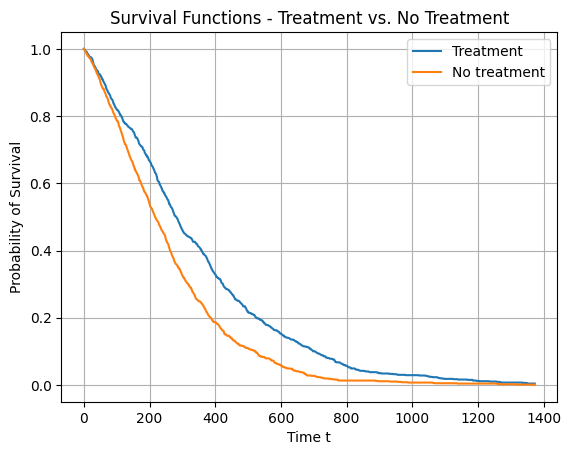

In [349]:
plt.plot(times_treatment, surval_treatment, label = "Treatment")
plt.plot(times_rate, surval_rate, label = "No treatment")
plt.title("Survival Functions - Treatment vs. No Treatment")
plt.xlabel("Time t")
plt.ylabel("Probability of Survival")
plt.legend()
plt.grid(True)
plt.show()


In [350]:
# The treatment appears to have an effect 

## Task 11

- Fixed time step, that cancer does only appear and disappear in one month time intervals 
- Assume that the time you stay in a state is exponentially distributed 
- Do waiting through Erlang distribution

# Part 3: Estimation

## Task 12

In [351]:
np.random.rand(42)
n_women = 1000
obs_times = np.arange(0, 48*10, 48)

times_series1 = []
for _ in range(n_women):
    Y = []
    j = 0
    history = sim_liftime_women_rate(Q_diag)

    for t in obs_times:
        
        while j + 1 < len(history) and history[j + 1][0] <= t:
            j += 1
    
        Y.append(history[j][1])
    
        if Y[-1] == 4: 
            break
        

    times_series1.append(Y)



In [352]:
times_series1

[[0, 0, 0, 0, np.int64(1), np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, np.int64(3), np.int64(3), np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, np.int64(2), np.int64(2), np.int64(2)],
 [0, 0, np.int64(1), np.int64(3), np.int64(3), np.int64(4)],
 [0, 0, 0, 0, np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(4)],
 [0, 0, 0, 0, 0, np.int64(2), np.int64(3), np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, np.int64(2), np.int64(3), np.int64(3), np.int64(4)],
 [0, 0, np.int64(1), np.int64(1), np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, np.int64(3), np.int64(4)],
 [0, np.int64(4)],
 [0,
  0,
  0,
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4)],
 [0, 0, 0, 0, np.int64(4)],
 [0, 0, np.int64(1), np.int64(1), np.int64(4)],
 [0, 0, 0, 0, 0, 0, np.int64(4)],
 [0, np.int64(2), np.int64(2), np.int6

## Task 13 

In [353]:
def simulate_markov(X0, X_end, Q, t):

    state = X0
    time = 48 * t
    end_time = 48 * (t + 1)

    history = [(time, state)]

    while True:

        rate = -Q[state, state]

        if state == 4:  # No going on after death
            break

        wait = np.random.exponential(1 / rate)

        if time + wait > end_time:
            break

        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs /= rate

        state = np.random.choice(len(Q), p=probs)

        history.append((time, state))

    # state at end_time
    if state == X_end:
        return history
    else:
        return False

In [354]:
def create_Q(Q0, time_series, eps):
    Q = Q0.copy()

    while True:

        # Create markov chains
        all_woman = []
        for woman in time_series: 
            history = [(0,0)]
            for t in range(len(woman[:-1])): 
                his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                while his_subset == False: 
                    his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                history.extend(his_subset[1:])
            all_woman.append(history)

        # Find Nij and Si
        n_states = 5 
        Nij = np.zeros((n_states,n_states))
        Si = np.zeros(n_states)

        for woman in all_woman:
        

            for k in range(len(woman) - 1):
            
                t_k, x_k = woman[k]
                t_next, x_next = woman[k + 1]
                
                # Sojourn time 

                Si[x_k] += (t_next - t_k)

                # jump count
                Nij[x_k, x_next] += 1

        # Find new Q

        Q_hat = np.zeros((n_states,n_states))

        for i in range(n_states):
            if Si[i] > 0:
                for j in range(n_states):
                    if i != j:
                        Q_hat[i, j] = Nij[i, j] / Si[i]

        for i in range(n_states):
            Q_hat[i, i] = -np.sum(Q_hat[i])
        
        if np.linalg.norm(Q - Q_hat, ord=np.inf) <= eps:
            break

        Q = Q_hat.copy()


    return Q_hat

In [355]:
time_series = times_series1
Q0 = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, -0.0140, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, -0.0080, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, -0.0090, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
])
eps = 10**-3
Q_hat = create_Q(Q0, time_series, eps)


In [356]:
Q_hat

array([[-6.98960531e-03,  4.42199520e-03,  1.66419174e-03,
         0.00000000e+00,  9.03418374e-04],
       [ 0.00000000e+00, -1.15960406e-02,  2.49377218e-05,
         4.38903903e-03,  7.18206387e-03],
       [ 0.00000000e+00,  0.00000000e+00, -1.21342159e-02,
         4.52573457e-03,  7.60848131e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.84162475e-02,  1.84162475e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -0.00000000e+00]])

In [357]:
Q_diag

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])